# Statistical Arbitrage & Mean Reversion

Detect cointegrated pairs, model mean-reverting spreads with Ornstein–Uhlenbeck processes, and backtest z-score-based pairs trading strategies.

**Theory references:** [Ornstein Uhlenbeck](../theory/04_stat_arb/ornstein_uhlenbeck.md) | [Cointegration](../theory/04_stat_arb/cointegration.md) | [Z-Score Signals](../theory/04_stat_arb/zscore_signals.md)

In [1]:
from __future__ import annotations

import os

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "normal",
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linewidth": 0.5,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})
COLORS = ["#534AB7", "#0F6E56", "#D85A30", "#185FA5", "#993556", "#3B6D11", "#BA7517"]


def save_fig(fig, topic: str, name: str) -> None:
    folder = os.path.join('..', 'plots', topic)
    os.makedirs(folder, exist_ok=True)
    for ext in ('pdf', 'png'):
        fig.savefig(os.path.join(folder, f'{name}.{ext}'))


## Section 1 — Ornstein-Uhlenbeck Process

The OU process $dX_t=\theta(\mu-X_t)\,dt+\sigma\,dW$ mean-reverts with Gaussian transitions, stationary variance $\sigma^2/(2\theta)$, and half-life $(\ln 2)/\theta$. Theory and estimation notes are in [ornstein_uhlenbeck.md](../theory/04_stat_arb/ornstein_uhlenbeck.md).


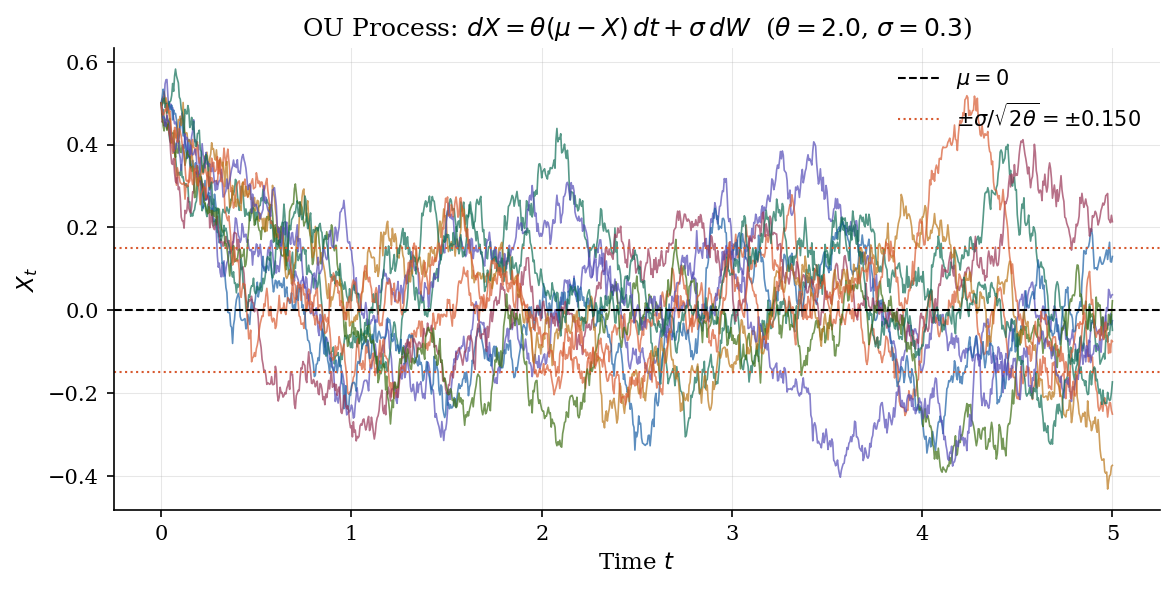

In [2]:
def simulate_ou(
    X0: float,
    theta: float,
    mu: float,
    sigma: float,
    T: float,
    n_steps: int,
    n_paths: int,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    """Simulate OU process paths using exact discretization.

    Uses the conditional distribution
    X_{t+dt} | X_t ~ N(mu + (X_t - mu)*exp(-theta*dt),
                       sigma^2*(1 - exp(-2*theta*dt)) / (2*theta)).

    Parameters
    ----------
    X0 : float
        Initial value.
    theta : float
        Mean reversion speed.
    mu : float
        Long-run mean.
    sigma : float
        Volatility.
    T : float
        Total time horizon.
    n_steps : int
        Number of time steps.
    n_paths : int
        Number of independent paths to simulate.
    rng : np.random.Generator
        Random number generator for reproducibility.

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        (t, paths) where t has shape (n_steps+1,) and paths has
        shape (n_paths, n_steps+1).
    """
    dt = T / n_steps
    t = np.linspace(0.0, T, n_steps + 1)
    paths = np.empty((n_paths, n_steps + 1))
    paths[:, 0] = X0

    decay = np.exp(-theta * dt)
    var_dt = sigma**2 * (1.0 - np.exp(-2.0 * theta * dt)) / (2.0 * theta)
    std_dt = np.sqrt(var_dt)

    for i in range(n_steps):
        paths[:, i + 1] = (
            mu + (paths[:, i] - mu) * decay + std_dt * rng.normal(size=n_paths)
        )

    return t, paths


rng = np.random.default_rng(42)
theta, mu, sigma_ou = 2.0, 0.0, 0.3
T, n_steps, n_paths = 5.0, 1000, 10

t, paths = simulate_ou(
    X0=0.5, theta=theta, mu=mu, sigma=sigma_ou,
    T=T, n_steps=n_steps, n_paths=n_paths, rng=rng,
)

stationary_std = sigma_ou / np.sqrt(2.0 * theta)

fig, ax = plt.subplots(figsize=(9, 4))
for k in range(n_paths):
    ax.plot(t, paths[k], lw=0.8, alpha=0.7, color=COLORS[k % len(COLORS)])
ax.axhline(mu, color="black", lw=1.0, ls="--", label=r"$\mu = 0$")
ax.axhline(
    mu + stationary_std, color=COLORS[2], lw=1.0, ls=":",
    label=rf"$\pm\sigma/\sqrt{{2\theta}} = \pm{stationary_std:.3f}$",
)
ax.axhline(mu - stationary_std, color=COLORS[2], lw=1.0, ls=":")
ax.set_xlabel(r"Time $t$")
ax.set_ylabel(r"$X_t$")
ax.set_title(
    r"OU Process: $dX = \theta(\mu - X)\,dt + \sigma\,dW$"
    rf"  ($\theta={theta}$, $\sigma={sigma_ou}$)"
)
ax.legend(frameon=False, loc="upper right")
save_fig(fig, "04_stat_arb", "ou_paths")
plt.show()

In [3]:
def estimate_ou_params(X: np.ndarray, dt: float) -> dict[str, float]:
    """Estimate OU parameters (theta, mu, sigma) from discrete observations via OLS.

    Fits the AR(1) regression  X_{i+1} = a + b * X_i + eps  derived from the
    exact OU transition, then maps back to continuous-time parameters:
        b     = exp(-theta * dt)
        a     = mu * (1 - b)
        theta = -ln(b) / dt
        mu    = a / (1 - b)
        sigma = sqrt(2 * theta * Var(eps) / (1 - exp(-2*theta*dt)))

    Parameters
    ----------
    X : np.ndarray
        Observed OU path, shape (N+1,).
    dt : float
        Time step between consecutive observations.

    Returns
    -------
    dict[str, float]
        Estimated parameters with keys 'theta', 'mu', 'sigma'.
    """
    X_prev, X_next = X[:-1], X[1:]
    slope, intercept = np.polyfit(X_prev, X_next, 1)

    theta_hat = -np.log(slope) / dt
    mu_hat = intercept / (1.0 - slope)

    residuals = X_next - (slope * X_prev + intercept)
    var_resid = np.var(residuals, ddof=1)
    sigma_hat = np.sqrt(
        2.0 * theta_hat * var_resid / (1.0 - np.exp(-2.0 * theta_hat * dt))
    )

    return {"theta": theta_hat, "mu": mu_hat, "sigma": sigma_hat}


t_long, paths_long = simulate_ou(
    X0=0.0, theta=theta, mu=mu, sigma=sigma_ou,
    T=50.0, n_steps=10_000, n_paths=1, rng=rng,
)
dt_long = 50.0 / 10_000

params_hat = estimate_ou_params(paths_long[0], dt_long)
print("Parameter estimation (N = 10,000 observations, T = 50):")
print(f"  theta: true = {theta:.3f},  estimated = {params_hat['theta']:.3f}")
print(f"  mu:    true = {mu:.3f},  estimated = {params_hat['mu']:.3f}")
print(f"  sigma: true = {sigma_ou:.3f},  estimated = {params_hat['sigma']:.3f}")

Parameter estimation (N = 10,000 observations, T = 50):
  theta: true = 2.000,  estimated = 1.491
  mu:    true = 0.000,  estimated = 0.045
  sigma: true = 0.300,  estimated = 0.300


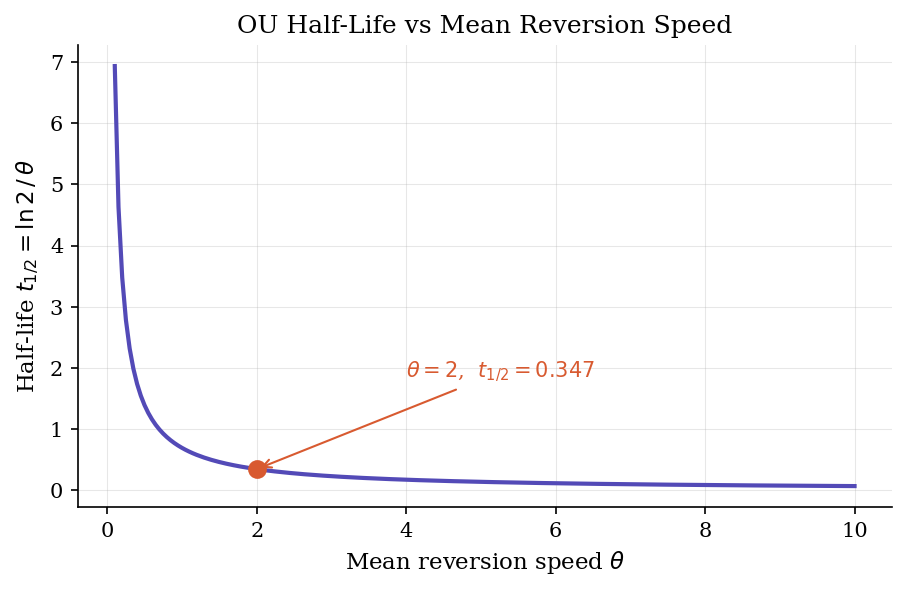

In [4]:
theta_range = np.linspace(0.1, 10.0, 200)
half_lives = np.log(2) / theta_range

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(theta_range, half_lives, color=COLORS[0], lw=2)

theta_mark = 2.0
hl_mark = np.log(2) / theta_mark
ax.plot(theta_mark, hl_mark, "o", color=COLORS[2], ms=8, zorder=5)
ax.annotate(
    rf"$\theta = {theta_mark:.0f}$,  $t_{{1/2}} = {hl_mark:.3f}$",
    xy=(theta_mark, hl_mark),
    xytext=(theta_mark + 2.0, hl_mark + 1.5),
    arrowprops=dict(arrowstyle="->", color=COLORS[2]),
    fontsize=10, color=COLORS[2],
)

ax.set_xlabel(r"Mean reversion speed $\theta$")
ax.set_ylabel(r"Half-life $t_{1/2} = \ln 2\,/\,\theta$")
ax.set_title("OU Half-Life vs Mean Reversion Speed")
save_fig(fig, "04_stat_arb", "ou_halflife_vs_theta")
plt.show()

## Section 2 — Cointegration and Pairs Trading

Cointegration yields a stationary spread $s_t=Y_t-\beta X_t$, which we test with Engle–Granger and trade using normalised $z$-scores of $s_t$. See [cointegration.md](../theory/04_stat_arb/cointegration.md) and [zscore_signals.md](../theory/04_stat_arb/zscore_signals.md).


In [5]:
def generate_cointegrated_pair(
    n_obs: int,
    beta: float,
    theta: float,
    mu_noise: float,
    sigma_noise: float,
    rng: np.random.Generator,
    X0: float = 50.0,
    sigma_X: float = 0.3,
) -> tuple[np.ndarray, np.ndarray]:
    """Generate a synthetic cointegrated pair Y = beta*X + OU_noise.

    X follows a random walk with N(0, sigma_X^2) increments.
    The spread (Y - beta*X) follows an OU process with the given
    parameters, simulated via exact discretization (dt = 1).

    Parameters
    ----------
    n_obs : int
        Number of observations to generate.
    beta : float
        Cointegrating coefficient.
    theta : float
        OU mean reversion speed for the spread.
    mu_noise : float
        Long-run mean of the OU spread component.
    sigma_noise : float
        Volatility of the OU spread component.
    rng : np.random.Generator
        Random number generator.
    X0 : float
        Starting price for X.
    sigma_X : float
        Standard deviation of X's random walk increments.

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        (X, Y) arrays each of shape (n_obs,).
    """
    X = np.empty(n_obs)
    X[0] = X0
    for i in range(1, n_obs):
        X[i] = X[i - 1] + sigma_X * rng.normal()

    dt = 1.0
    decay = np.exp(-theta * dt)
    ou_var = sigma_noise**2 * (1.0 - np.exp(-2.0 * theta * dt)) / (2.0 * theta)
    ou_std = np.sqrt(ou_var)

    Z = np.empty(n_obs)
    Z[0] = mu_noise
    for i in range(1, n_obs):
        Z[i] = mu_noise + (Z[i - 1] - mu_noise) * decay + ou_std * rng.normal()

    Y = beta * X + Z
    return X, Y


rng_pair = np.random.default_rng(7)
n_obs = 1000
beta_true = 1.5

X_price, Y_price = generate_cointegrated_pair(
    n_obs=n_obs, beta=beta_true, theta=1.0,
    mu_noise=0.0, sigma_noise=0.5, rng=rng_pair,
    X0=50.0, sigma_X=0.3,
)

print(f"Generated {n_obs} observations of a cointegrated pair (beta = {beta_true}).")
print(f"X range: [{X_price.min():.2f}, {X_price.max():.2f}]")
print(f"Y range: [{Y_price.min():.2f}, {Y_price.max():.2f}]")

Generated 1000 observations of a cointegrated pair (beta = 1.5).
X range: [21.04, 50.09]
Y range: [31.73, 75.17]


In [6]:
X_with_const = sm.add_constant(X_price)
ols_result = sm.OLS(Y_price, X_with_const).fit()
alpha_hat, beta_hat = ols_result.params

print(f"OLS regression: Y = {alpha_hat:.4f} + {beta_hat:.4f} * X")
print(f"True beta = {beta_true:.4f},  estimated beta = {beta_hat:.4f}")
print()

spread = ols_result.resid

adf_stat, adf_pval, _, _, crit_values, _ = adfuller(spread, autolag="AIC")
print("ADF test on spread residuals:")
print(f"  Test statistic: {adf_stat:.4f}")
print(f"  p-value:        {adf_pval:.6f}")
for level, cv in crit_values.items():
    print(f"  Critical value ({level}): {cv:.4f}")
if adf_pval < 0.05:
    print("  => Reject H0 (unit root) at 5%: spread is stationary. Cointegration confirmed.")
else:
    print("  => Fail to reject H0: no evidence of cointegration.")

OLS regression: Y = 0.0528 + 1.4983 * X
True beta = 1.5000,  estimated beta = 1.4983

ADF test on spread residuals:
  Test statistic: -13.9563
  p-value:        0.000000
  Critical value (1%): -3.4369
  Critical value (5%): -2.8644
  Critical value (10%): -2.5683
  => Reject H0 (unit root) at 5%: spread is stationary. Cointegration confirmed.


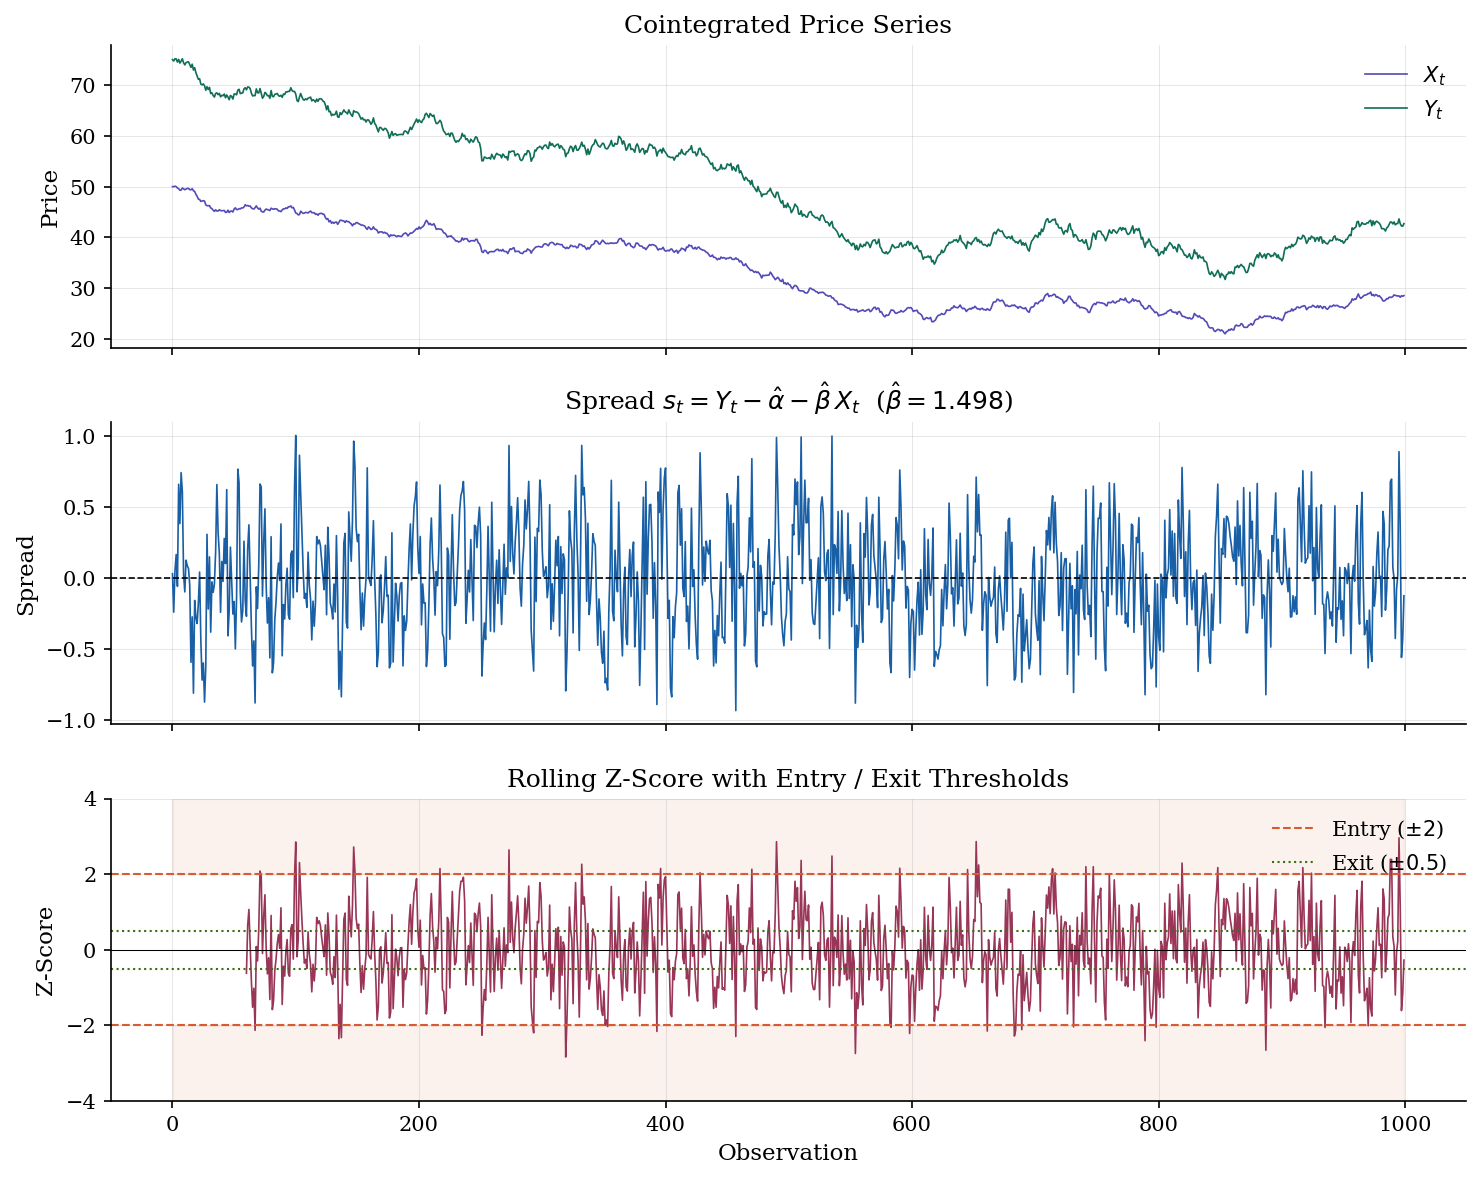

In [7]:
def rolling_zscore(x: np.ndarray, window: int) -> np.ndarray:
    """Compute rolling z-score with a backward-looking window.

    For each index i >= window, the z-score is computed using the mean
    and std of x[i-window : i] (the previous *window* observations,
    excluding the current value). Indices before *window* are NaN.

    Parameters
    ----------
    x : np.ndarray
        Input time series, shape (n,).
    window : int
        Lookback window length.

    Returns
    -------
    np.ndarray
        Z-scores, shape (n,). NaN for the first *window* entries.
    """
    n = len(x)
    z = np.full(n, np.nan)
    for i in range(window, n):
        win = x[i - window : i]
        mu_w = np.mean(win)
        sd_w = np.std(win, ddof=1)
        if sd_w > 1e-10:
            z[i] = (x[i] - mu_w) / sd_w
    return z


z_score = rolling_zscore(spread, window=60)
obs_idx = np.arange(n_obs)

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(obs_idx, X_price, color=COLORS[0], lw=0.8, label=r"$X_t$")
axes[0].plot(obs_idx, Y_price, color=COLORS[1], lw=0.8, label=r"$Y_t$")
axes[0].set_ylabel("Price")
axes[0].set_title("Cointegrated Price Series")
axes[0].legend(frameon=False)

axes[1].plot(obs_idx, spread, color=COLORS[3], lw=0.8)
axes[1].axhline(0, color="black", lw=0.8, ls="--")
axes[1].set_ylabel("Spread")
axes[1].set_title(
    rf"Spread $s_t = Y_t - \hat{{\alpha}} - \hat{{\beta}}\,X_t$"
    rf"  ($\hat{{\beta}} = {beta_hat:.3f}$)"
)

axes[2].plot(obs_idx, z_score, color=COLORS[4], lw=0.8)
axes[2].axhline(2.0, color=COLORS[2], lw=1.0, ls="--", label=r"Entry ($\pm 2$)")
axes[2].axhline(-2.0, color=COLORS[2], lw=1.0, ls="--")
axes[2].axhline(0.5, color=COLORS[5], lw=1.0, ls=":", label=r"Exit ($\pm 0.5$)")
axes[2].axhline(-0.5, color=COLORS[5], lw=1.0, ls=":")
axes[2].axhline(0, color="black", lw=0.5)
axes[2].fill_between(obs_idx, 2.0, 4.0, alpha=0.08, color=COLORS[2])
axes[2].fill_between(obs_idx, -4.0, -2.0, alpha=0.08, color=COLORS[2])
axes[2].set_ylim(-4, 4)
axes[2].set_ylabel("Z-Score")
axes[2].set_xlabel("Observation")
axes[2].set_title("Rolling Z-Score with Entry / Exit Thresholds")
axes[2].legend(frameon=False, loc="upper right")

fig.tight_layout()
save_fig(fig, "04_stat_arb", "cointegration_zscore")
plt.show()

## Section 3 — Backtest

The backtest enters when the spread’s $z$-score is large and exits on reversion to the inner band, and the code sweeps entry and exit thresholds on the synthetic series.


Round-trip trades: 44
Annualized Sharpe: 3.058
Final PnL:         34.615


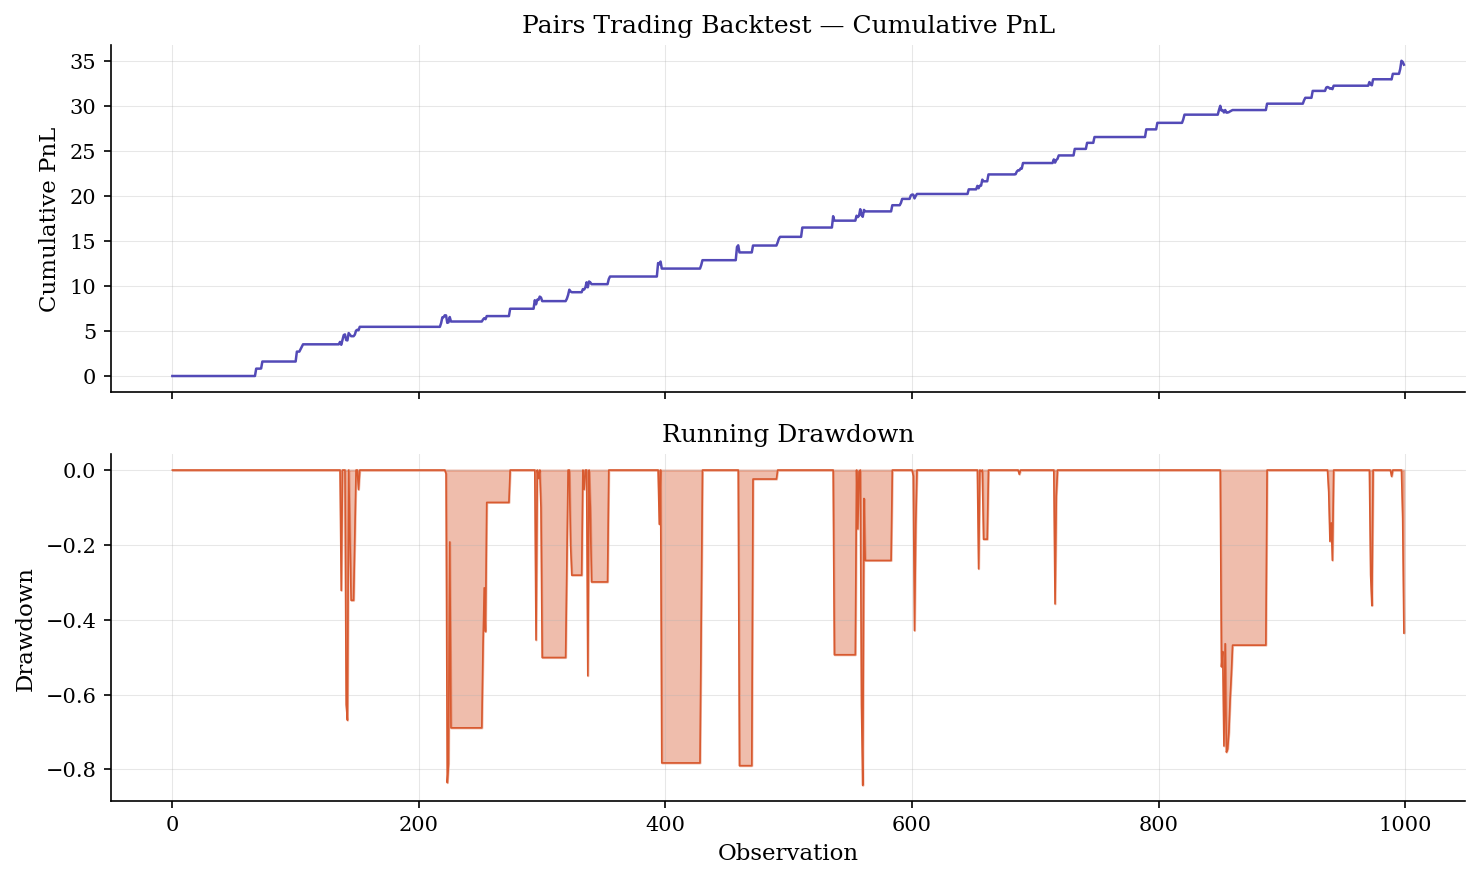

In [8]:
def backtest_pairs(
    spread: np.ndarray,
    z_entry: float = 2.0,
    z_exit: float = 0.5,
    lookback: int = 60,
) -> dict:
    """Backtest a pairs trading strategy on the spread.

    Entry: go long spread when z < -z_entry, short when z > z_entry.
    Exit: when |z| < z_exit.

    The rolling z-score is computed with a backward-looking window of
    length *lookback*, using only past data (no look-ahead).

    Parameters
    ----------
    spread : np.ndarray
        Spread time series, shape (n,).
    z_entry : float
        Z-score threshold to enter a position (absolute value).
    z_exit : float
        Z-score threshold to exit a position (absolute value).
    lookback : int
        Rolling window length for z-score computation.

    Returns
    -------
    dict
        'pnl'       : cumulative PnL array, shape (n,)
        'positions'  : position array (+1, 0, -1), shape (n,)
        'trades'     : number of round-trip trades
        'sharpe'     : annualized Sharpe ratio (252 trading days)
    """
    n = len(spread)
    positions = np.zeros(n)
    pos = 0.0
    trades = 0

    for i in range(lookback, n):
        win = spread[i - lookback : i]
        mu_w = np.mean(win)
        sd_w = np.std(win, ddof=1)
        z_i = (spread[i] - mu_w) / sd_w if sd_w > 1e-10 else 0.0

        if pos == 0.0:
            if z_i < -z_entry:
                pos = 1.0
                trades += 1
            elif z_i > z_entry:
                pos = -1.0
                trades += 1
        elif abs(z_i) < z_exit:
            pos = 0.0

        positions[i] = pos

    spread_ret = np.diff(spread)
    daily_pnl = positions[:-1] * spread_ret
    cum_pnl = np.concatenate([[0.0], np.cumsum(daily_pnl)])

    valid_pnl = daily_pnl[lookback:]
    if len(valid_pnl) > 1 and np.std(valid_pnl) > 1e-10:
        sharpe = float(np.mean(valid_pnl) / np.std(valid_pnl) * np.sqrt(252))
    else:
        sharpe = 0.0

    return {
        "pnl": cum_pnl,
        "positions": positions,
        "trades": trades,
        "sharpe": sharpe,
    }


bt = backtest_pairs(spread, z_entry=2.0, z_exit=0.5, lookback=60)
print(f"Round-trip trades: {bt['trades']}")
print(f"Annualized Sharpe: {bt['sharpe']:.3f}")
print(f"Final PnL:         {bt['pnl'][-1]:.3f}")

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(obs_idx, bt["pnl"], color=COLORS[0], lw=1.2)
axes[0].set_ylabel("Cumulative PnL")
axes[0].set_title("Pairs Trading Backtest — Cumulative PnL")

running_max = np.maximum.accumulate(bt["pnl"])
drawdown = bt["pnl"] - running_max
axes[1].fill_between(obs_idx, drawdown, 0, color=COLORS[2], alpha=0.4)
axes[1].plot(obs_idx, drawdown, color=COLORS[2], lw=0.8)
axes[1].set_ylabel("Drawdown")
axes[1].set_xlabel("Observation")
axes[1].set_title("Running Drawdown")

fig.tight_layout()
save_fig(fig, "04_stat_arb", "pairs_backtest_pnl")
plt.show()

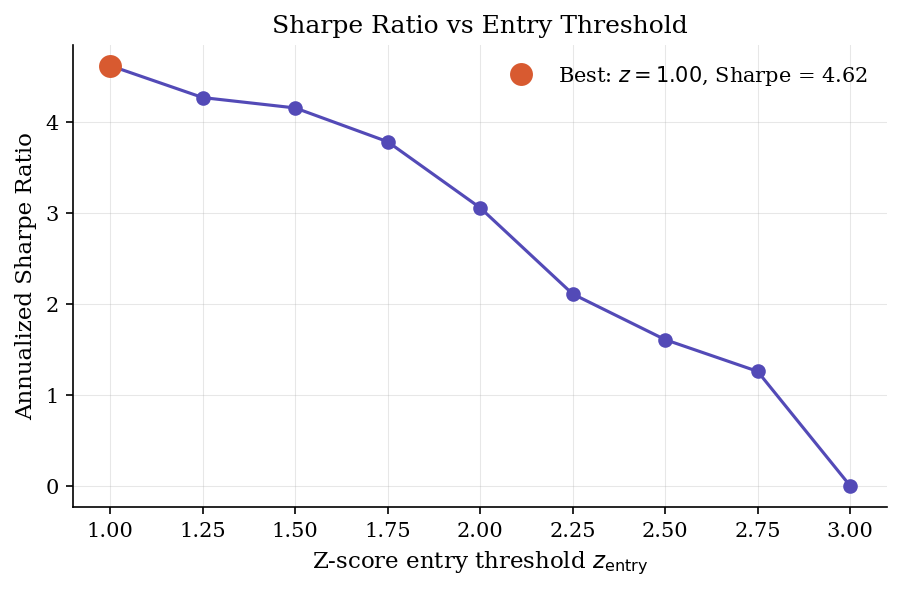

In [9]:
thresholds = np.arange(1.0, 3.25, 0.25)
sharpes = []

for z_ent in thresholds:
    result = backtest_pairs(spread, z_entry=z_ent, z_exit=0.5, lookback=60)
    sharpes.append(result["sharpe"])

sharpes_arr = np.array(sharpes)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, sharpes_arr, "o-", color=COLORS[0], lw=1.5, ms=6)
ax.set_xlabel(r"Z-score entry threshold $z_{\mathrm{entry}}$")
ax.set_ylabel("Annualized Sharpe Ratio")
ax.set_title("Sharpe Ratio vs Entry Threshold")

best_idx = int(np.argmax(sharpes_arr))
ax.plot(
    thresholds[best_idx], sharpes_arr[best_idx], "o",
    color=COLORS[2], ms=10, zorder=5,
    label=rf"Best: $z = {thresholds[best_idx]:.2f}$, Sharpe = {sharpes_arr[best_idx]:.2f}",
)
ax.legend(frameon=False)

save_fig(fig, "04_stat_arb", "sharpe_vs_threshold")
plt.show()

## Prosperity 4 Takeaways

Mean reversion must be fast enough that the half-life fits inside a round before you rely on a pairs signal. Start near $z_{\mathrm{entry}}=2$, tune rolling windows to the tick noise, and you can skew Avellaneda–Stoikov quotes with the same $z$-signal when both engines run together.
